Trabajas en una empresa emergente que vende productos alimenticios. Debes investigar el comportamiento del usuario para la aplicación de la empresa.

Primero, estudia el embudo de ventas. Descubre cómo los usuarios llegan a la etapa de compra. ¿Cuántos usuarios realmente llegan a esta etapa? ¿Cuántos se atascan en etapas anteriores? ¿Qué etapas en particular?

Luego, observa los resultados de un test A/A/B (sigue leyendo para obtener más información sobre los test A/A/B). Al equipo de diseño le gustaría cambiar las fuentes de toda la aplicación, pero la gerencia teme que los usuarios piensen que el nuevo diseño es intimidante. Por ello, deciden tomar una decisión basada en los resultados de un test A/A/B.

Los usuarios se dividen en tres grupos: dos grupos de control obtienen las fuentes antiguas y un grupo de prueba obtiene las nuevas. Descubre qué conjunto de fuentes produce mejores resultados.

Crear dos grupos A tiene ciertas ventajas. Podemos establecer el principio de que solo confiaremos en la exactitud de nuestras pruebas cuando los dos grupos de control sean similares. Si hay diferencias significativas entre los grupos A, esto puede ayudarnos a descubrir factores que pueden estar distorsionando los resultados. La comparación de grupos de control también nos dice cuánto tiempo y datos necesitaremos cuando realicemos más tests.

Utilizarás el mismo dataset para el análisis general y para el análisis A/A/B. En proyectos reales, los experimentos se llevan a cabo constantemente. El equipo de análisis estudia la calidad de una aplicación utilizando datos generales, sin prestar atención a si los usuarios participan en experimentos.

# Instrucciones para completar el proyecto

## Paso 1. Abrir el archivo de datos y leer la información general

In [34]:
# 1.1 Importar librerias
import pandas as pd 
import seaborn as nsn
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import math 

In [2]:
# 1.2 Cargar archivo
logs = pd.read_csv('/datasets/logs_exp_us.csv', sep= "\t")

El siguiente procedimiento nos ayudara a identificar nombres correctos de columnas, revisión de valores ausentes, tipos de datos.Esto nos serviria para definir una mejor estrategia que nos ayude a facilitar el analisis.

In [3]:
logs.info()
logs.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


## Paso 2. Preparar los datos para el análisis

En este bloque vamos a cambiar el nombre de las columnas, no se observa valores ausentes, cambiar el tipo de dato a datetime en la columna eventTimestamp.

1.- cambiar nombres de columnas



In [4]:
logs.rename(columns={"EventName": "event",
    "DeviceIDHash":"user",
    "EventTimestamp":"date",
    "ExpId":"exp_id"}, inplace=True)

In [5]:
logs.head()

,event,user,date,exp_id
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [6]:
# Cambiar la columna date a datetime
logs["date_time"] = pd.to_datetime(logs["date"], unit="s")
logs["date_dt"] = logs["date_time"].dt.floor("1D")

In [7]:
logs.head()

,event,user,date,exp_id,date_time,date_dt
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
3,CartScreenAppear,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,2019-07-25 11:48:42,2019-07-25


# Paso 3. Estudiar y comprobar los datos

In [8]:
# ¿Cuántos eventos hay en los registros?
logs["event"].count()

244126

In [9]:
# ¿Cuántos usuarios hay en los registros?
logs["user"].nunique()

7551

In [10]:
# ¿Cuál es el promedio de eventos por usuario?
logs["event"].count() /logs["user"].nunique()

32.33028737915508

In [11]:
# ¿Qué periodo de tiempo cubren los datos? Encuentra la fecha máxima y mínima.
logs["date_time"].min()

Timestamp('2019-07-25 04:43:36')

In [12]:
logs["date_time"].max()

Timestamp('2019-08-07 21:15:17')

<AxesSubplot:>

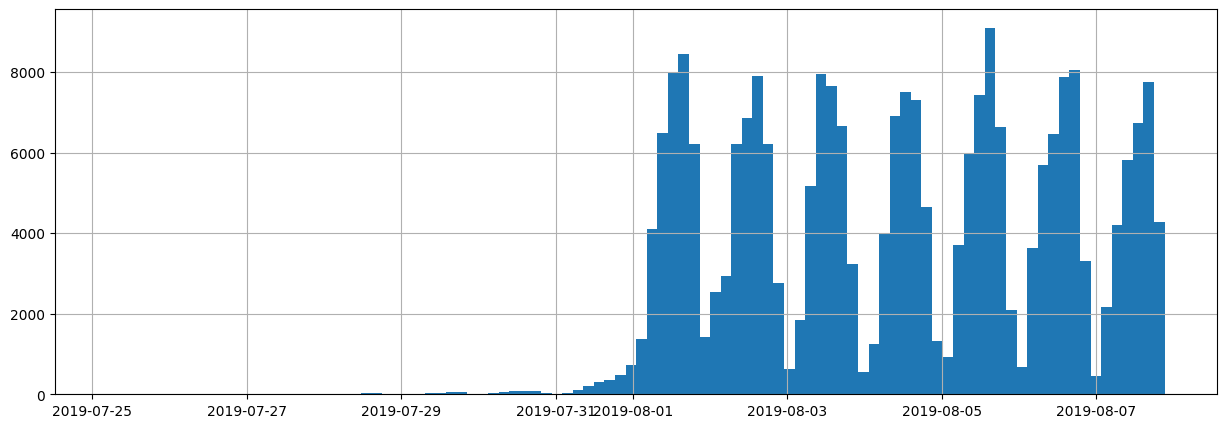

In [13]:
# Traza un histograma por fecha y hora. 
logs["date_time"].hist(bins=100, figsize=(15,5))

In [14]:
# Encuentra el momento en el que los datos comienzan a estar completos e ignora la sección anterior.¿Qué periodo representan realmente los datos?
completo = logs.pivot_table(index="date_dt",
                           values="user",
                           aggfunc="count")


<AxesSubplot:xlabel='date_dt'>

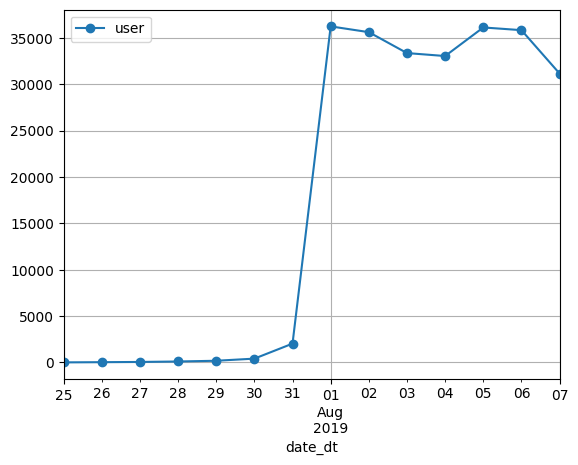

In [15]:
completo.plot(style="o-",grid=True)

como conclusión apartir del  1ro de agosto los datos comienzan a estar completos

In [16]:
logs_filtrado =logs[logs["date_dt"]> "2019-07-31"]

In [17]:
logs_filtrado["date_dt"].min()

Timestamp('2019-08-01 00:00:00')

In [18]:
#¿Perdiste muchos eventos y usuarios al excluir los datos más antiguos?

In [19]:
# ¿Cuántos eventos hay en los registros?
logs_filtrado["event"].count()

241298

In [20]:
# ¿Cuántos usuarios hay en los registros?
logs_filtrado["user"].nunique()

7534

In [21]:
# ¿Cuál es el promedio de eventos por usuario?
logs_filtrado["event"].count() /logs_filtrado["user"].nunique()

32.02787363950093

In [22]:
# Asegúrate de tener usuarios de los tres grupos experimentales.
logs_filtrado["exp_id"].value_counts()

248    84726
246    79425
247    77147
Name: exp_id, dtype: int64

## Paso 4. Estudiar el embudo de eventos

Observa qué eventos hay en los registros y su frecuencia de suceso. Ordénalos por frecuencia.

In [23]:
logs_filtrado["event"].value_counts()

MainScreenAppear           117431
OffersScreenAppear          46350
CartScreenAppear            42365
PaymentScreenSuccessful     34113
Tutorial                     1039
Name: event, dtype: int64

Encuentra la cantidad de usuarios que realizaron cada una de estas acciones. Ordena los eventos por el número de usuarios. Calcula la proporción de usuarios que realizaron la acción al menos una vez.

In [24]:
usuarios_evento = logs_filtrado.pivot_table(index="event",
                         values="user",
                         aggfunc="nunique").sort_values(by="user",ascending=False)

In [25]:
usuarios_evento / len(logs["user"].unique())

,user
event,
MainScreenAppear,0.982519
OffersScreenAppear,0.608264
CartScreenAppear,0.494504
PaymentScreenSuccessful,0.468680
Tutorial,0.111244


¿En qué orden crees que ocurrieron las acciones? ¿Todas son parte de una sola secuencia? No es necesario tenerlas en cuenta al calcular el embudo.

En conclusión vemos que el tutorial es opcional y la secuencia es Mainscreenappear, luego offersScreenAppear, luego CartScreenAppear y por último Paymentscreensuccessful.

Utiliza el embudo de eventos para encontrar la proporción de usuarios que pasan de una etapa a la siguiente. Por ejemplo, para la secuencia de eventos A → B → C, calcula la proporción de usuarios en la etapa B a la cantidad de usuarios en la etapa A y la proporción de usuarios en la etapa C a la cantidad en la etapa B.

In [26]:
usuario_embudo = usuarios_evento[:-1]
usuario_embudo = (usuario_embudo / usuario_embudo.shift())
usuario_embudo

,user
event,
MainScreenAppear,NaN
OffersScreenAppear,0.619086
CartScreenAppear,0.812976
PaymentScreenSuccessful,0.947777


¿En qué etapa pierdes más usuarios?

En conclusión vemos que se pierde en el evento MainScreenAppear puesto que no hay usuarios o tiene valores nulos.

¿Qué porcentaje de usuarios hace todo el viaje desde su primer evento hasta el pago?

In [27]:
usuarios_evento.loc["PaymentScreenSuccessful"] / usuarios_evento.loc["MainScreenAppear"]

user    0.477018
dtype: float64

# Paso 5. Estudiar los resultados del experimento

In [28]:
# ¿Cuántos usuarios hay en cada grupo?
user_per_group = logs.pivot_table(index="exp_id",
            values="user",
                aggfunc="nunique")
user_per_group

,user
exp_id,
246,2489
247,2520
248,2542


Tenemos dos grupos de control en el test A/A, donde comprobamos nuestros mecanismos y cálculos. Observa si hay una diferencia estadísticamente significativa entre las muestras 246 y 247.

In [29]:
user_event_group = logs.pivot_table(index="event",
                values="user",
                 columns="exp_id",
                aggfunc="nunique")
user_event_group

exp_id,246,247,248
event,,,
CartScreenAppear,1270,1240,1239
MainScreenAppear,2456,2482,2501
OffersScreenAppear,1545,1530,1538
PaymentScreenSuccessful,1202,1160,1185
Tutorial,279,286,282


Selecciona el evento más popular. En cada uno de los grupos de control, encuentra la cantidad de usuarios que realizaron esta acción. Encuentra su proporción. Comprueba si la diferencia entre los grupos es estadísticamente significativa. Repite el procedimiento para todos los demás eventos (ahorrarás tiempo si creas una función especial para esta prueba). ¿Puedes confirmar que los grupos se dividieron correctamente?

In [37]:

def prueba_z(exitos1,exitos2,intentos1,intentos2,alpha = .05):
    p1 = exitos1/intentos1
    p2 = exitos2/intentos2
    p_combined = (exitos1 + exitos2) / (intentos1 + intentos2)
    difference = p1-p2
    
    z_value = difference / math.sqrt(p_combined *(1 - p_combined) * (1/intentos1 + 1/intentos2))
    
    distr = stats.norm(0,1)
    
    p_value = (1 - distr.cdf(abs(z_value))) * 2
    
    print('p-value: ', p_value)
    
    if (p_value < alpha):
        print("Rechazar la hipótesis nula: hay una diferencia significativa entre las proporciones")
    else:
        print("No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes")



In [38]:
# probar la funcion
e1 = user_event_group.loc["MainScreenAppear",246]
e2 = user_event_group.loc["MainScreenAppear",247]
i1 = user_per_group.loc[246]
i2 = user_per_group.loc[247]

prueba_z(e1,e2,i1,i2)

p-value:  [0.58566398]
No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes


In [39]:
# funcion para eventos
def hipotesis_eventos(usuario_evento_grupo,usuario_por_grupo,evento,exp1,exp2):
    frac1=usuario_evento_grupo.loc[evento,exp1]/usuario_por_grupo.loc[exp1]
    frac2=usuario_evento_grupo.loc[evento,exp2]/usuario_por_grupo.loc[exp2]
    print(f"{frac1} con el {evento} evento en el grupo {exp1}")
    print(f"{frac2} con el {evento} evento en el grupo {exp2}")
    prueba_z(usuario_evento_grupo.loc[evento,exp1],
             usuario_evento_grupo.loc[evento,exp2],
             usuario_por_grupo.loc[exp1],
             usuario_por_grupo.loc[exp2])    

In [40]:
# bucle for
for event in user_event_group.index:
    hipotesis_eventos(user_event_group,user_per_group,event,246,247)
    print()

user    0.510245
Name: 246, dtype: float64 con el CartScreenAppear evento en el grupo 246
user    0.492063
Name: 247, dtype: float64 con el CartScreenAppear evento en el grupo 247
p-value:  [0.19817541]
No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes

user    0.986742
Name: 246, dtype: float64 con el MainScreenAppear evento en el grupo 246
user    0.984921
Name: 247, dtype: float64 con el MainScreenAppear evento en el grupo 247
p-value:  [0.58566398]
No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes

user    0.620731
Name: 246, dtype: float64 con el OffersScreenAppear evento en el grupo 246
user    0.607143
Name: 247, dtype: float64 con el OffersScreenAppear evento en el grupo 247
p-value:  [0.3233225]
No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes

user    0.482925
Name: 246, dtype: float64 con el PaymentScreenSuccessful evento en e

Haz lo mismo para el grupo con fuentes alteradas. Compara los resultados con los de cada uno de los grupos de control para cada evento de forma aislada. Compara los resultados con los resultados combinados de los grupos de control. ¿Qué conclusiones puedes sacar del experimento?

In [41]:
for event in user_event_group.index:
    hipotesis_eventos(user_event_group,user_per_group,event,247,248)
    print()

user    0.492063
Name: 247, dtype: float64 con el CartScreenAppear evento en el grupo 247
user    0.487411
Name: 248, dtype: float64 con el CartScreenAppear evento en el grupo 248
p-value:  [0.74060946]
No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes

user    0.984921
Name: 247, dtype: float64 con el MainScreenAppear evento en el grupo 247
user    0.983871
Name: 248, dtype: float64 con el MainScreenAppear evento en el grupo 248
p-value:  [0.7632161]
No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes

user    0.607143
Name: 247, dtype: float64 con el OffersScreenAppear evento en el grupo 247
user    0.605035
Name: 248, dtype: float64 con el OffersScreenAppear evento en el grupo 248
p-value:  [0.87805745]
No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes

user    0.460317
Name: 247, dtype: float64 con el PaymentScreenSuccessful evento en e

¿Qué nivel de significancia has establecido para probar las hipótesis estadísticas mencionadas anteriormente? Calcula cuántas pruebas de hipótesis estadísticas has realizado. Con un nivel de significancia estadística de 0.1, uno de cada 10 resultados podría ser falso. ¿Cuál debería ser el nivel de significancia? Si deseas cambiarlo, vuelve a ejecutar los pasos anteriores y comprueba tus conclusiones.

Se utilizo alpha 0.05,

In [42]:
def prueba_z(exitos1,exitos2,intentos1,intentos2,alpha = .1):
    p1 = exitos1/intentos1
    p2 = exitos2/intentos2
    p_combined = (exitos1 + exitos2) / (intentos1 + intentos2)
    difference = p1-p2
    
    z_value = difference / math.sqrt(p_combined *(1 - p_combined) * (1/intentos1 + 1/intentos2))
    
    distr = stats.norm(0,1)
    
    p_value = (1 - distr.cdf(abs(z_value))) * 2
    
    print('p-value: ', p_value)
    
    if (p_value < alpha):
        print("Rechazar la hipótesis nula: hay una diferencia significativa entre las proporciones")
    else:
        print("No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes")



In [43]:
# probar la funcion
e1 = user_event_group.loc["MainScreenAppear",246]
e2 = user_event_group.loc["MainScreenAppear",247]
i1 = user_per_group.loc[246]
i2 = user_per_group.loc[247]

prueba_z(e1,e2,i1,i2)

p-value:  [0.58566398]
No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes


In [ ]:
# funcion para eventos
def hipotesis_eventos(usuario_evento_grupo,usuario_por_grupo,evento,exp1,exp2):
    frac1=usuario_evento_grupo.loc[evento,exp1]/usuario_por_grupo.loc[exp1]
    frac2=usuario_evento_grupo.loc[evento,exp2]/usuario_por_grupo.loc[exp2]
    print(f"{frac1} con el {evento} evento en el grupo {exp1}")
    print(f"{frac2} con el {evento} evento en el grupo {exp2}")
    prueba_z(usuario_evento_grupo.loc[evento,exp1],
             usuario_evento_grupo.loc[evento,exp2],
             usuario_por_grupo.loc[exp1],
             usuario_por_grupo.loc[exp2])

In [44]:
# bucle for
for event in user_event_group.index:
    hipotesis_eventos(user_event_group,user_per_group,event,246,247)
    print()

user    0.510245
Name: 246, dtype: float64 con el CartScreenAppear evento en el grupo 246
user    0.492063
Name: 247, dtype: float64 con el CartScreenAppear evento en el grupo 247
p-value:  [0.19817541]
No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes

user    0.986742
Name: 246, dtype: float64 con el MainScreenAppear evento en el grupo 246
user    0.984921
Name: 247, dtype: float64 con el MainScreenAppear evento en el grupo 247
p-value:  [0.58566398]
No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes

user    0.620731
Name: 246, dtype: float64 con el OffersScreenAppear evento en el grupo 246
user    0.607143
Name: 247, dtype: float64 con el OffersScreenAppear evento en el grupo 247
p-value:  [0.3233225]
No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes

user    0.482925
Name: 246, dtype: float64 con el PaymentScreenSuccessful evento en e

In [45]:
for event in user_event_group.index:
    hipotesis_eventos(user_event_group,user_per_group,event,247,248)
    print()

user    0.492063
Name: 247, dtype: float64 con el CartScreenAppear evento en el grupo 247
user    0.487411
Name: 248, dtype: float64 con el CartScreenAppear evento en el grupo 248
p-value:  [0.74060946]
No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes

user    0.984921
Name: 247, dtype: float64 con el MainScreenAppear evento en el grupo 247
user    0.983871
Name: 248, dtype: float64 con el MainScreenAppear evento en el grupo 248
p-value:  [0.7632161]
No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes

user    0.607143
Name: 247, dtype: float64 con el OffersScreenAppear evento en el grupo 247
user    0.605035
Name: 248, dtype: float64 con el OffersScreenAppear evento en el grupo 248
p-value:  [0.87805745]
No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes

user    0.460317
Name: 247, dtype: float64 con el PaymentScreenSuccessful evento en e

En conclusión parece que el nivel de significancia estadistica no varia con los alpha ya sea con 0.1 o 0.05 solo cambian algunos resultados cuando combinamos los grupos 246 y 247 o 247 y 248 según los p_value mostrado arriba.

## CONCLUSIONES GENERALES

Empezamos cargando las librerias y abriendo nuestro archivo logs como priemer paso, continuamos con el segundo paso en preparar los datos para el análisis donde cambiamos los nombres de las columnas comprobamos los tipos de datos y verificamos que no hubiera valores ausentes solo tuvimos que modificar nuestra columna date y por último agregamos 2 columnas donde separamos la fechas y la hora, continuamos con el paso 3 en estudiar y comprobar los datos donde nos pedian cuantos eventos y usuarios estan registrados y su promedio,encontrar la fecha minima y maxima trazando un histograma por fecha y hora y encontrando el momento en que los datos empiezan a estar completos, donde se pieden muchos eventos y usuarios excluyendo los mas antiguos y por último asegurarnos de tener los usuarios de los tres grupos experimentales,en el paso 4 se estudio el embudo de eventos donde ordenamos los eventos que tienen registros y su frecuencia, encontramos la cantidad de usuarios que realizan estas acciones  ordenando los eventos por el número de usuarios,en que orden ocurrieron las acciones,utilizamos el embudo de eventos para encontrar la proporción de usuarios que pasan de una etapa a la siguiente, en que estapa se pierden mas usuarios y su porcentaje de usuarios que hacen todo el viaje, y por último paso 5 estudiar los resultados del experimento empezamos con cuantos usuarios hay en cada grupo, si hay significancia estadisticamente entre los grupos 246 y 247, seleccionar el evento mas popular encontramos su proporcion e hicimos una función especial para realizar la prueba,hicimos lo mismo con 248 y comparamos los resultados con cada uno de los grupos para cada evento de forma aislada.                                                                           